In [ ]:
!pip install mlflow

In [ ]:
import mlflow

mlflow.set_experiment("Create In-Country Folds")
with mlflow.start_run(run_name="Create In-Country Folds"):
    # Seu código para criar folds in-country
    mlflow.log_param("method", "cross_validation")
    mlflow.log_artifact("../data/processed/folds", artifact_path="folds")
    mlflow.log_param("input", "Directory with TFRecord files: ../data/processed/tfrecords/")
    mlflow.log_param("output", "Directory containing training and validation data folds: ../data/processed/folds/")
    mlflow.set_tag("aws_instance_type", "2vCPU + 8 GiB")

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Pre-requisites" data-toc-modified-id="Pre-requisites-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Pre-requisites</a></span></li><li><span><a href="#Instructions" data-toc-modified-id="Instructions-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Instructions</a></span></li><li><span><a href="#Imports-and-Constants" data-toc-modified-id="Imports-and-Constants-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Imports and Constants</a></span></li><li><span><a href="#Calculate-Locations-Statistics" data-toc-modified-id="Calculate-Locations-Statistics-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Calculate Locations Statistics</a></span></li><li><span><a href="#Create-In-country-Folds" data-toc-modified-id="Create-In-country-Folds-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Create In-country Folds</a></span></li></ul></div>

## Pre-requisites

None

## Instructions

Households surveyed by DHS and LSMS are grouped into clusters (roughly villages). Our goal is to train models to predict the average cluster wealth-index given a satellite image of the cluster. To train our models, we assign the clusters into training (`train`), validation (`val`), and test (`test`) splits.

However, we do not arbitrarily assign clusters to splits because many clusters are located very close to each other such that their satellite images overlap. If one cluster was put in `train` and a nearby cluster was put into `test`, this may constitute "peaking" at the test set. This is not what we want. Instead, we want our model to be generalizable, able to estimate the cluster wealth-index in grographic regions that the model has not necessarily seen before.

Thus, we have to take special care that the satellite images between splits do not overlap. We do this through 2 separate approaches: "out-of-country" and "in-country". For "**out-of-country**" splits, we assign entire countries to a split, so naturally there is no overlap between splits. For "**in-country**" splits, we allow different clusters within the same country to be assigned to different splits, taking care that their satellite images have no overlap. **The point of this notebook is to create the in-country splits.**

Because the survey data is fairly limited (~20K DHS clusters, ~3K LSMS clusters), we actually use cross-validated training. We assign the clusters to 1 of 5 folds labeled `['A', 'B', 'C', 'D', 'E']` such that the folds are non-overlapping. Given the 5 folds, we create 5 different sets of train/val/test splits, where each set is labeled by the name of its `test` fold:

```
A) test  = {A}
   val   = {B}
   train = {C, D, E}

B) test  = {B}
   val   = {C}
   train = {D, E, A}

...

E) test  = {E}
   val   = {A}
   train = {B, C, D}
```

This notebook creates 2 Python pickle files: `data/dhs_incountry_folds.pkl` and `data/lsms_incountry_folds.pkl`. Each of these files contains a pickle'd Python dictionary which can be loaded as follows:

```python
with open('data/dhs_incountry_folds.pkl', 'rb') as f:
    dhs_incountry_folds = pickle.load(f)
```

The dictionary has type `Dict[str, Dict[str, np.ndarray]` such that `dhs_incountry_folds[f][s]` returns an array of indices corresponding to split `s` of fold `f`. The indices correspond to 0-indexed rows from `data/dhs_clusters.csv` and `data/lsms_clusters.csv`.

```python
dhs_incountry_folds = {
    'A': {'test':  array([   28,    29,    35, ..., 19662, 19664, 19667]),
          'train': array([    2,     3,     4, ..., 19663, 19665, 19668]),
          'val':   array([    0,     1,     8, ..., 19643, 19659, 19666])},
    ...
    'E': {'test':  array([    2,     3,     4, ..., 19653, 19656, 19663]),
          'train': array([    0,     1,     6, ..., 19665, 19666, 19668]),
          'val':   array([   28,    29,    35, ..., 19662, 19664, 19667])}}
```

## Imports and Constants

Downloading the Libraries

In [4]:
!apt-get install -y libproj-dev proj-d|ata proj-bin
!apt-get install -y libgeos-dev
!apt-get install -y -qq libgdal-dev libproj-dev
!pip install cython
!pip install cartopy
!pip install matplotlib
!pip install pandas

/bin/sh: 1: ata: not found
E: Unable to locate package proj-d
Reading package lists... Done
Building dependency tree       
Reading state information... Done
libgeos-dev is already the newest version (3.6.2-1build2).
0 upgraded, 0 newly installed, 0 to remove and 13 not upgraded.
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/g/glib2.0/libglib2.0-data_2.56.4-0ubuntu0.18.04.6_all.deb  404  Not Found [IP: 185.125.190.36 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/i/icu/libicu60_60.2-3ubuntu3.1_amd64.deb  404  Not Found [IP: 185.125.190.36 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/o/openssl/libssl1.1_1.1.1-1ubuntu2.1~18.04.7_amd64.deb  404  Not Found [IP: 185.125.190.36 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/libx/libxml2/libxml2_2.9.4+dfsg1-6.1ubuntu1.3_amd64.deb  404  Not Found [IP: 185.125.190.36 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/m/mysql-5.7/libmysqlclient20_5.7.3

In [7]:
!pip install scipy

     |████████████████████████████████| 25.9 MB 18.2 MB/s eta 0:00:01
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [11]:
!pip install scikit-learn

     |████████████████████████████████| 22.2 MB 18.2 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 74.7 MB/s eta 0:00:01
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [16]:
!pip install Cartopy

  Using cached Cartopy-0.19.0.post1.tar.gz (12.1 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  ERROR: Command errored out with exit status 1:
   command: /usr/bin/python3 /usr/local/lib/python3.6/dist-packages/pip/_vendor/pep517/_in_process.py get_requires_for_build_wheel /tmp/tmp9i9506tp
       cwd: /tmp/pip-install-wtm4izvj/cartopy_8caee8b63fd94e178dcffc7a849c2f42
  Complete output (1 lines):
  Proj 4.9.0 must be installed.
  ----------------------------------------
ERROR: Command errored out with exit status 1: /usr/bin/python3 /usr/local/lib/python3.6/dist-packages/pip/_vendor/pep517/_in_process.py get_requires_for_build_wheel /tmp/tmp9i9506tp Check the logs for full command output.
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [19]:
!apt-get update
!apt-get install libproj-dev proj-data proj-bin
Y

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  InRelease [1581 B]
Get:2 http://security.ubuntu.com/ubuntu bionic-security InRelease [88.7 kB]    
Err:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  InRelease
  The following signatures couldn't be verified because the public key is not available: NO_PUBKEY A4B469963BF863CC
Ign:3 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu bionic InRelease                  
Get:5 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  Release [564 B]
Get:6 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  Release.gpg [833 B]
Get:7 http://archive.ubuntu.com/ubuntu bionic-updates InRelease [88.7 kB]
Get:8 http://security.ubuntu.com/ubuntu bionic-security/restricted amd64 Packages [1688 kB]
Get:9 http://security.ubuntu.com/ubuntu bio

In [20]:
import pickle
from pprint import pprint

import numpy as np
import pandas as pd

#from batchers import dataset_constants
from preprocessing.create_folds import (
   create_folds,
   create_split_folds,
   save_folds,
   verify_folds)

Important Constants - Fold Names and minimun distance between Folds of the same group

In [21]:
FOLDS = ['A', 'B', 'C', 'D', 'E']
MIN_DIST = 0.092841  # see how this value is computed below

Paths to Required Files

In [22]:
BASE_PATH =  "/home/sagemaker-user/reproducible/data/processed/"
#PROCESSED_PATH = BASE_PATH+"processed/"

# Path to the .csv File - Created in 2.1 Code
DATASET_CSV_PATH = BASE_PATH + "clusters_data_9000.0km.csv"
# Path to the Folds File - Output of this Code
FOLDS_PKL_OUTPUT_PATH = BASE_PATH + "dhs_incountry_co.pkl"

## Calculate Locations Statistics

We want to group our surveyed clusters into 5 folds such that there is absolutely no overlap between the satellite images from different folds. In other words, if any part of an image *i1* covers the same geographic area as another image *i2*, then we must put the clusters corresponding to *i1* and *I2* into the same fold.

We have the (lat, lon) coordinates for each cluster, so our approach is to determine the threshold "radius" around each cluster that would be considered part of the same fold. We know that our satellite images have 30m/px resolution, and our models use `224*224px` center crops of the images. This means that each image has a side length of 30m/px * 224px = **6.72km**. Thus, we try to convert 6.72km to degrees (lat, lon).

Note that the degrees longitude corresponding to a given East-West distance (in meters) changes depends on the latitude. Thus, converting between traditional units of distance (e.g., meters) and degrees lat/lon is non-trivial. This section calculates the maximum degrees (lat, lon) equivalent to 6.72km at the location of any cluster in our dataset.

The results computed should match the following:

|                                                | DHS        | LSMS
|-----------------------------------------------:|-----------:|-----------:|
| minimum latitude                               | -30.588811 | -16.985500
| maximum latitude                               |  16.580605 |  14.455962
| minimum longitude                              | -17.478474 |   2.969085
| maximum longitude                              |  47.007920 |  43.870658
| maximum image side-length in degrees latitude  |   0.060570 |   0.060570
| maximum image side-length in degrees longitude |   0.070361 |   0.063333

This means that for the purpose of deciding image overlap, we assume each satellite image to have width=0.070361° and height=0.060570°. (We take the maximum across the DHS and LSMS datasets.) Because images may overlap in corners, we consider any two images within $$\sqrt{0.060570^2 + 0.070361^2} = 0.092841$$ degrees (lat, lon) to be overlapping. This is the value of the `MIN_DIST` constant above.

In [23]:
RADIUS_EARTH = 6356.7523  # in km, polar radius of Earth

def get_lon_for_distance(lat: float, d: float) -> float:
    '''Calculates the degrees longitude for some East-West distance at a given latitude.

    Makes (imperfect) assumption that Earth is a perfect sphere.
    Uses the smaller polar radius (instead of equatorial radius), so
        actual degrees longitude <= returned value

    Args
    - lat: float, latitude in degrees
    - d: float, distance in km

    Returns
    - lon: float, approximate degrees longitude
    '''
    lat = np.abs(lat) * np.pi / 180.0  # convert to radians
    r = RADIUS_EARTH * np.cos(lat)  # radius at the given lat
    lon = d / r
    lon = lon * 180.0 / np.pi  # convert to degrees
    return lon

def get_lat_for_distance(d: float) -> float:
    '''Calculates the degrees latitude for some North-South distance.

    Makes (incorrect) assumption that Earth is a perfect sphere.
    Uses the smaller polar radius (instead of equatorial radius), so
        actual degrees latitude <= returned value

    Args
    - d: float, distance in km

    Returns
    - lat: float, approximate degrees latitude
    '''
    lat = d / RADIUS_EARTH  # in radians
    lat = lat * 180.0 / np.pi  # convert to degrees
    return lat

def print_loc_stats(locs: np.ndarray) -> None:
    '''
    Args
    - locs: np.array, shape [N, 2], each row is [lat, lon] in degrees
        assumes lat values are + for N, - for S
        assumes lon values are + for E, - for W
    '''
    min_lat, min_lon = np.min(locs, axis=0)
    max_lat, max_lon = np.max(locs, axis=0)
    print(f'Lat. min: {min_lat:.6f}, max: {max_lat:.6f}')
    print(f'Lon. min: {min_lon:.6f}, max: {max_lon:.6f}')
    print()

    # get maximum lat/lon side-lengths for a 224x224 pixel image at 30m / px
    side_distance = 224 * 30 / 1000
    farthest_lat = max(abs(min_lat), abs(max_lat))
    side_lat = get_lat_for_distance(d=side_distance)
    side_lon = get_lon_for_distance(lat=farthest_lat, d=side_distance)
    print(f'maximum side_lat: {side_lat:.6f}')
    print(f'maximum side_lon: {side_lon:.6f}')

In [24]:
dhs_df = pd.read_csv(DATASET_CSV_PATH, float_precision='high', index_col=False)
dhs_locs = dhs_df[['lat', 'lon']].values
print_loc_stats(dhs_locs)
dhs_df.describe()

Lat. min: -24.937995, max: -2.364476
Lon. min: -60.688729, max: -35.221490

maximum side_lat: 0.060570
maximum side_lon: 0.066798


,year,lat,lon,income,literacy,longevity
count,23719.0,23719.000000,23719.000000,23719.000000,23719.000000,23719.000000
mean,2010.0,-13.182300,-48.010099,0.488830,0.832228,0.736297
std,0.0,5.017138,5.824026,0.123602,0.118178,0.086876
min,2010.0,-24.937995,-60.688729,0.022813,0.114262,0.133333
25%,2010.0,-17.268157,-52.523043,0.383836,0.759397,0.696294
50%,2010.0,-13.305273,-47.672140,0.506226,0.858989,0.751613
75%,2010.0,-9.074964,-43.629721,0.591530,0.928337,0.792054
max,2010.0,-2.364476,-35.221490,1.000000,1.000000,1.000000


MIN_DIST = 0.086## Create In-country Folds

Using the DBSCAN algorithm, we group the survey clusters such that each group has a minimum distance of `MIN_DIST` from every other group. These are called "in-country" folds because different clusters from same country may be split across different folds. This is in contrast to the "out-of-country" (OOC) folds where the countries themselves are assigned to different folds.

In [25]:
MIN_DIST = 0.086

num clusters: 1089
num outliers: 842
max cluster size (excl. outliers): 14348


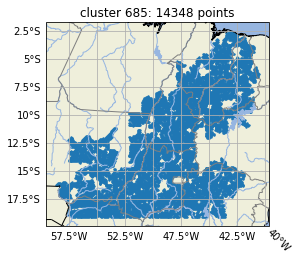

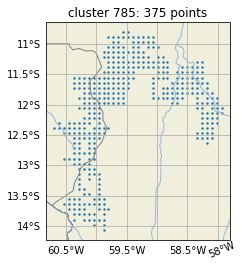

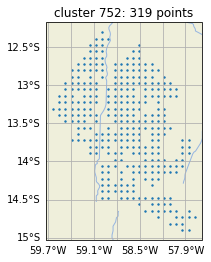

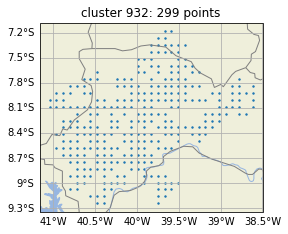

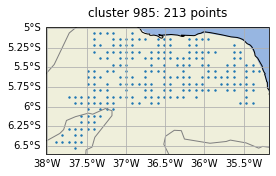

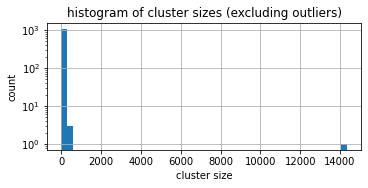

Size of each fold
{'A': 14348, 'B': 2343, 'C': 2343, 'D': 2343, 'E': 2342}
Minimum distance between each pair of folds
A B 0.08601565594676686
A C 0.08601565594676686
A D 0.08601565594676686
A E 0.08601565594676686
B C 0.08601565594676686
B D 0.08605945016274674
B E 0.08605945016274674
C D 0.08605945016274674
C E 0.08605945016274674
D E 0.08605945016274674


In [27]:
dhs_incountry_test_folds = create_folds(
    locs=dhs_locs,
    min_dist=MIN_DIST,
    fold_names=FOLDS,
    plot_largest_clusters=5)

verify_folds(
    folds=dhs_incountry_test_folds,
    locs=dhs_locs,
    min_dist=MIN_DIST,
    max_index=len(dhs_locs))

dhs_incountry_folds = create_split_folds(
    test_folds=dhs_incountry_test_folds,
    fold_names=FOLDS)

save_folds(
    folds_path=FOLDS_PKL_OUTPUT_PATH,
    folds=dhs_incountry_folds,
    check_exists=False)

In [28]:
with open(FOLDS_PKL_OUTPUT_PATH,'rb') as f:
    dhs_incountry_folds = pickle.load(f)
    print(dhs_incountry_folds)

{'A': {'test': array([   96,    97,    98, ..., 23700, 23701, 23702]), 'val': array([    0,     1,     2, ..., 23507, 23703, 23705]), 'train': array([   99,   286,   482, ..., 23716, 23717, 23718])}, 'B': {'test': array([    0,     1,     2, ..., 23507, 23703, 23705]), 'val': array([  530,   674,   675, ..., 23716, 23717, 23718]), 'train': array([   96,    97,    98, ..., 23701, 23702, 23711])}, 'C': {'test': array([  530,   674,   675, ..., 23716, 23717, 23718]), 'val': array([   99,   286,   482, ..., 23488, 23542, 23711]), 'train': array([    0,     1,     2, ..., 23702, 23703, 23705])}, 'D': {'test': array([   99,   286,   482, ..., 23488, 23542, 23711]), 'val': array([  516,   619,   620, ..., 23195, 23672, 23683]), 'train': array([    0,     1,     2, ..., 23716, 23717, 23718])}, 'E': {'test': array([  516,   619,   620, ..., 23195, 23672, 23683]), 'val': array([   96,    97,    98, ..., 23700, 23701, 23702]), 'train': array([    0,     1,     2, ..., 23716, 23717, 23718])}}
